# U.S. GDP Curve Fitting Project

## Introduction

In [41]:
import numpy as np
import matplotlib.pyplot as plt

x = np.array([1, 5, 9, 13, 17, 19, 22, 25, 27, 28,
              29, 33, 37, 41, 42, 43, 45, 49, 54, 56])
y = np.array([1.7, 0.1, 2.3, 2.7, 1.7, 5.0, 3.0, 1.5, 3.5, 1.8,
              1.3, 2.5, 3.1, -5.1, -28.1, 33.8, 6.3, -1.6, 2.4, 3.3])
print(x)

[ 1  5  9 13 17 19 22 25 27 28 29 33 37 41 42 43 45 49 54 56]


## Part A: Cubic Spline

In [42]:
def setup_tridiagonal_matrix(x, y):
    """
    Constructs coefficients arrays for tridiagonal system to solve for second derivatives
    """
    h = np.diff(x)
    A = []
    B = []
    C = []
    D = []
    
    for i in range(1, len(x)-1):
        leftSlope = (y[i] - y[i-1]) / h[i-1]
        rightSlope = (y[i+1] - y[i]) / h[i]
        A.append(h[i-1])
        B.append(2 * (h[i-1] + h[i]))
        C.append(h[i])
        D.append(6 * (rightSlope - leftSlope))
        
    return A, B, C, D

In [43]:
def thomas_algorithm(a, b, c, d):
    """
    Solves tridiagonal system
    """
    n = len(b)
    for i in range(1, n):
        w = a[i-1] / b[i-1]
        b[i] = b[i] - w * c[i-1]
        d[i] = d[i] - w * d[i-1]
    x = np.zeros(n)
    x[-1] = d[-1] / b[-1]
    for i in range(n-2, -1, -1):
        x[i] = (d[i] - c[i] * x[i+1]) / b[i]
    m = np.concatenate(([0], x, [0]))
    return m

In [44]:
def evaluate_spline(x, y, m, xeval):
    """
    Uses the second derivatives to compute the spline value at any point given
    """
    lowerBound = 0
    upperBound = 1
    for i in range(len(x)-1):
        if (x[i] <= xeval <= x[i+1]):
            lowerBound = i
            upperBound = i+1
            break
    xL = x[lowerBound]
    xU = x[upperBound]
    yL = y[lowerBound]
    yU = y[upperBound]
    mL = m[lowerBound]
    mU = m[upperBound]
    h = xU - xL
    leftCurve = mL * (xU - xeval)**3 / (6*h)
    rightCurve = mU * (xeval - xL)**3 / (6*h)
    left = (yL - mL*h**2/6) * (xU - xeval) / h
    right = (yU - mU*h**2/6) * (xeval - xL) / h
    yValue = leftCurve + rightCurve + left + right
    return yValue

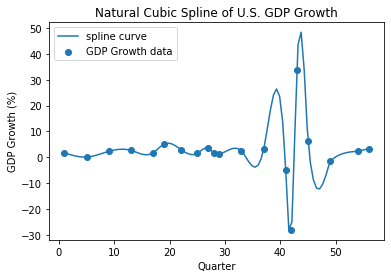

In [57]:
a, b, c, d = setup_tridiagonal_matrix(x, y)
m = thomas_algorithm(a, b, c, d)
xnew = np.linspace(min(x), max(x),100)
ynew = []
for i in xnew:
    ynew.append(evaluate_spline(x, y, m, i))
plt.scatter(x, y, label="GDP Growth data")
plt.plot(xnew, ynew, label = "spline curve")
plt.legend()
plt.xlabel("Quarter")
plt.ylabel("GDP Growth (%)")
plt.title("Natural Cubic Spline of U.S. GDP Growth")
plt.show()

We are solving for the second derivative at each point. With 20 data points, there are 18 unknowns because natural spline boundary gives that the second derivative at the endpoints is zero. At each interior knot, it is required that the spline satisfies: the continuity of the function, the first derivative, and the second derivative match. This means each segment matches in value, slope, and concavity. 
The interpolant is visually smooth in most regions of the graph; however, in the COVID-19 region, large oscillation is exhibited between points. This is due to the spline trying to interpolate these outlier points, leading to an unrealistic curve in the graph. As a result, the graph is not a fully accurate or reasonable representation of data in these areas.
The spline passes through two severe outliers, 2020 Q2 and Q3 with values of -28.1% and 33.8% respectively. This causes the interpolant to bend and produce large oscillations. This reflects the Runge phenomenon, where interpolating in high order can lead to large oscillations especially with extreme data values. Forcing the interpolation to be exact between these vastly differing values leads to a decrease in numerical stability which results in unreasonable behavior. This showcases the trade-off between exact interpolation and stability. Exact interpolation guarantees the curve goes through each point, but it results in inaccurate results when outliers are included. In the case of this data, a smoothing splines or weighted least squares method would be ideal due to the presence of outliers. Either of these methods would result in a more reasonable approximation.

## Part B: Polynomial & Least Squares

In [46]:
def leastSq(X,Y):
    n = len(X)
    sumX = sum(X)
    sumY = sum(Y)
    sumX2 = sum(X**2)
    sumXY = sum(X*Y)
    m = ((n * sumXY) - (sumX * sumY))/((n * sumX2) - (sumX**2))
    c = (sumY - (m * sumX))/n
    return m,c

In [47]:
def polyLeastSq(x, y, degree):
    A = []
    for num in x:
        row = []
        for i in range(0,degree+1):
            row.append(num**i)
        A.append(row)
    A = np.array(A)
    y = np.array(y)
    AT = A.T
    ATA = AT @ A
    ATy = AT @ y
    c = np.linalg.solve(ATA, ATy)
    return c

In [71]:
def evalPoly(c, xvals):
    yval = []
    for x in xvals:
        x = float(x)
        total = 0.0
        for num in range(len(c)):
            total += c[num] * (x**num)
        yval.append(total)
    return yval

In [72]:
def r2(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred)**2)
    ss_tot = np.sum((y_true - np.mean(y_true))**2)
    return 1 - (ss_res / ss_tot)

In [73]:
def mse(y_true, y_pred):
    return np.mean((y_true - y_pred)**2)

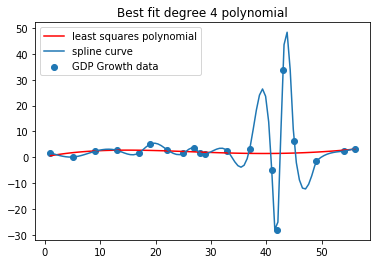

Polynomial R^2 = -7.736784818768683e+56
Polynomial MSE = 7.813177832069204e+58


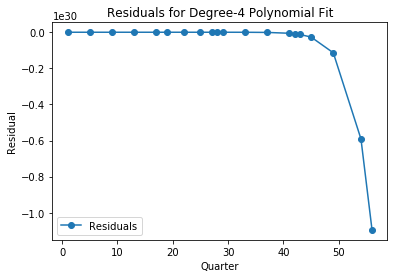

In [80]:
xSpread = np.linspace(min(x), max(x),100)
c4 = polyLeastSq(x, y, 4)
ypoly = evalPoly(c4, xSpread)

plt.figure()
plt.scatter(x, y, label="GDP Growth data")
plt.plot(xSpread, ypoly, color="red", label = "least squares polynomial")

a, b, c, d = setup_tridiagonal_matrix(x, y)
m = thomas_algorithm(a, b, c, d)
xnew = np.linspace(min(x), max(x),100)
ynew = []
for i in xnew:
    ynew.append(evaluate_spline(x, y, m, i))
plt.plot(xnew, ynew, label = "spline curve")

plt.legend()
plt.title("Best fit degree 4 polynomial")
plt.show()

print("Polynomial R^2 =", r2(y, y_poly))
print("Polynomial MSE =", mse(y, y_poly))

y_poly = evalPoly(c, x)
res_poly = y - y_poly
plt.figure()
plt.plot(x, res_poly, 'o-', label='Residuals')
plt.xlabel("Quarter")
plt.ylabel("Residual")
plt.title("Residuals for Degree-4 Polynomial Fit")
plt.legend()
plt.show()

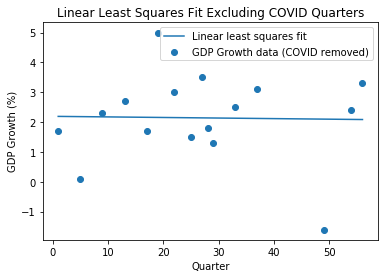

Slope = -0.00190698818897635
Linear R^2 = 0.0004432944068258893
Linear MSE = 2.082787240095964


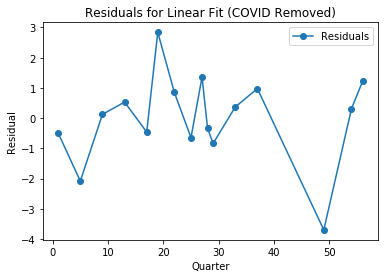

In [81]:
covid_indices = [13, 14, 15, 16]
x_filtered = np.delete(x, covid_indices)
y_filtered = np.delete(y, covid_indices)

m, c = leastSq(x_filtered, y_filtered)
y_line = m * x_filtered + c

plt.figure()
plt.scatter(x_filtered, y_filtered, label="GDP Growth data (COVID removed)")
plt.plot(x_filtered, y_line, label="Linear least squares fit")
plt.xlabel("Quarter")
plt.ylabel("GDP Growth (%)")
plt.title("Linear Least Squares Fit Excluding COVID Quarters")
plt.legend()
plt.show()

print("Slope =", m)
print("Linear R^2 =", r2(y_filtered, y_line))
print("Linear MSE =", mse(y_filtered, y_line))

res_linear = y_filtered - y_line

plt.figure()
plt.plot(x_filtered, res_linear, 'o-', label='Residuals')
plt.xlabel("Quarter")
plt.ylabel("Residual")
plt.title("Residuals for Linear Fit (COVID Removed)")
plt.legend()
plt.show()

The degree 4 polynomial captures the overall trend of the data better than the spline. The spline goes through each data point, catering to the COVID outliers. This results in extreme values and oscillations. On the other hand, the degree 4 polynomial smooths out oscillations focuses on the general trend.
The linear fit excluding COVID data gives the most accurate long-term representation of GDP growth. This model is more stable due to the exclusion of the extreme values due from the COVID region. The slope of the graph is -0.00190698818897635 which represents the average change in GDP growth per quarter. The residual models show that both models are not completely accurate representations of the data.

## Part C: Method Justification

I would recommend to a policymaker estimating GDP for a quarter between two known data points to use polynomial fitting. These two different approaches to modeling the data have distinct differences. The degree-4 polynomial has a higher R squared value and a lower mean squared error than the spline. This indicates smaller overall error, showing the polynomial model is superior in catching the trend.
The cubic spline passes through every data point which causes the curve to bend and oscillate in order to correct to extreme values. This is especially noticeable in the COVID region, a region where the spline had large oscillations. This made the spline an unreasonable representation of the overall trend of the data. In contrast, the polynomial fitting was steady through this abnormal region which reflected the overall pattern of the GDP growth better.
Overall, the polynomial fitting is a better option for estimating GDP between data points due to the fact it is accurate as well as stable.


## Conclusion

The degree 4 polynomial fitting provided more stable interpolation of the data better in the presence of outliers. The cubic spline model goes through every point, so it exhibits large oscillations in the presence of extreme values. This is present throughout the COVID region of this data. This makes it less reliable for estimating values between points. Cubic splines are designed for exact interpolation. The polynomial fitting model represents a smooth and stable curve, even in the presence of the outliers. This is shown by the higher R squared value as well as the low mean squared error. This allows the polynomial fitting model to capture the overall trend of the GDP growth better.
The least squares linear model was the least accurate because it assumes the rate of change was constant. It did not capture the the variability of the data. When models prioritize exactness, they give up the factor of stability when outliers are included in the data. There is a clear trade between exact interpolation and numerical stability. Polynomial fitting tends to be the most accurate in situations like this, providing the best estimates for real world predictions. This is an important factor in economic prediction and analysis.